In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# Store Item Demand Forecasting — Time Series Project

**Author:** Zakee Ul Hassan
**Dataset:** [Kaggle: Store Item Demand Forecasting](https://www.kaggle.com/competitions/demand-forecasting-kernels-only/data) — 913K rows of daily sales
**Goal:** Forecast next 3 months of daily sales across 50 items × 10 stores. Compare baseline, classical (ARIMA/SARIMA), and ML approaches with walk-forward validation.

In [2]:
df = pd.read_csv('../data/train.csv')
print("Shape:",df.shape)
df.head()


Shape: (913000, 4)


,date,store,item,sales
0,2013-01-01,1,1,13
1,2013-01-02,1,1,11
2,2013-01-03,1,1,14
3,2013-01-04,1,1,13
4,2013-01-05,1,1,10


In [3]:
df['date'] = pd.to_datetime(df['date'])
print("Date column dtype:", df['date'].dtype)
print("Date range:", df['date'].min(), "→", df['date'].max())

Date column dtype: datetime64[ns]
Date range: 2013-01-01 00:00:00 → 2017-12-31 00:00:00


In [4]:
print("Total rows:", len(df))
print("Total days:", (df['date'].max() - df['date'].min()).days + 1)
print("Unique stores:", df['store'].nunique())
print("Unique items:", df['item'].nunique())
print("Total combinations:", df['store'].nunique() * df['item'].nunique())
print("Rows per store-item:", len(df) / (df['store'].nunique() * df['item'].nunique()))

Total rows: 913000
Total days: 1826
Unique stores: 10
Unique items: 50
Total combinations: 500
Rows per store-item: 1826.0


In [5]:
print("Sales summary statistics:")
print(df['sales'].describe())
print("\nMissing values:")
print(df.isnull().sum())

Sales summary statistics:
count    913000.000000
mean         52.250287
std          28.801144
min           0.000000
25%          30.000000
50%          47.000000
75%          70.000000
max         231.000000
Name: sales, dtype: float64

Missing values:
date     0
store    0
item     0
sales    0
dtype: int64


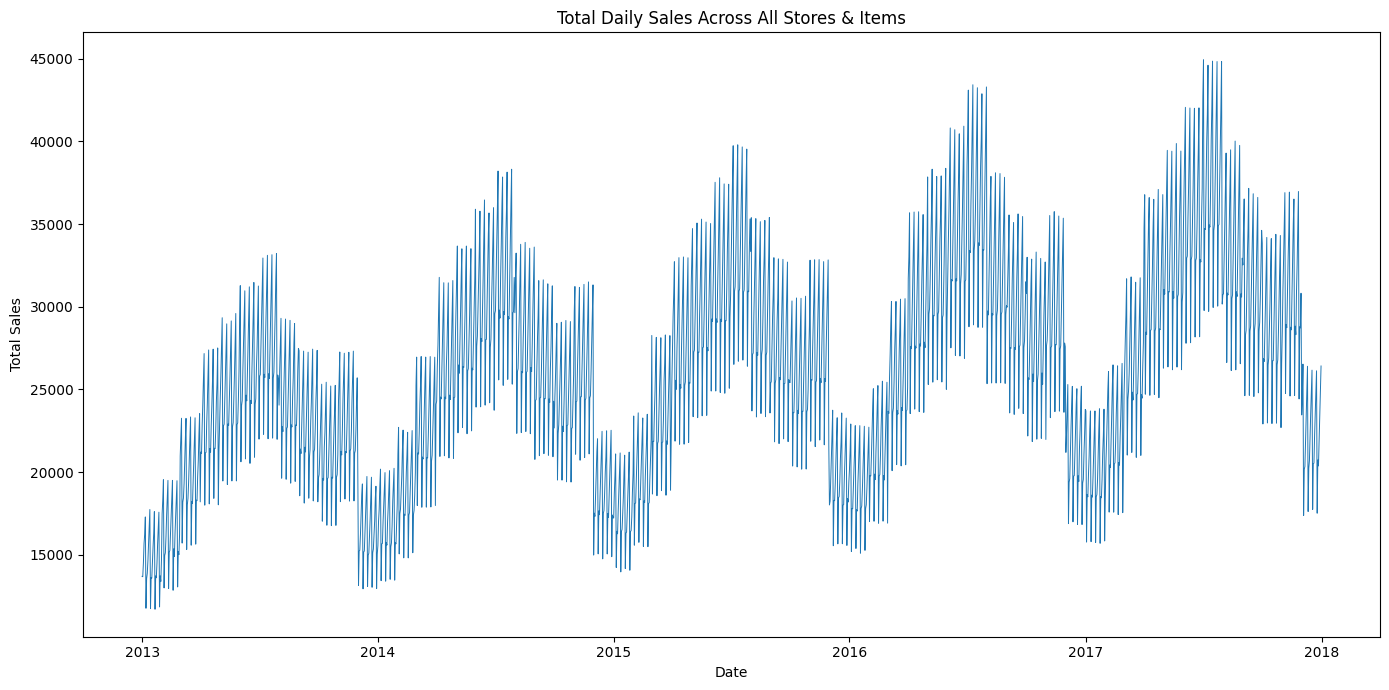

In [6]:
daily_total = df.groupby("date")["sales"].sum().reset_index()

plt.figure(figsize=(14, 7))
plt.plot(daily_total['date'], daily_total['sales'], linewidth=0.7)
plt.title('Total Daily Sales Across All Stores & Items')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.tight_layout()
plt.savefig('../total_daily_sales.png', dpi=100, bbox_inches='tight')
plt.show()

In [7]:
daily_total.head()

,date,sales
0,2013-01-01,13696
1,2013-01-02,13678
2,2013-01-03,14488
3,2013-01-04,15677
4,2013-01-05,16237


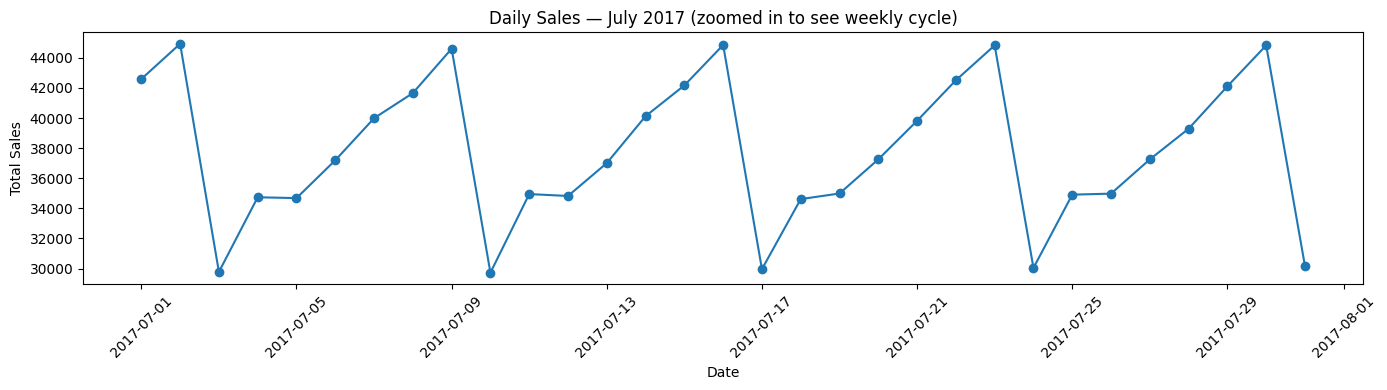

In [8]:
# Zoom in on one month to see weekly pattern
sample_month = daily_total[(daily_total['date'] >= '2017-07-01') & (daily_total['date'] <= '2017-07-31')]

plt.figure(figsize=(14, 4))
plt.plot(sample_month['date'], sample_month['sales'], marker='o', linewidth=1.5)
plt.title('Daily Sales — July 2017 (zoomed in to see weekly cycle)')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../weekly_cycle.png', dpi=100, bbox_inches='tight')
plt.show()

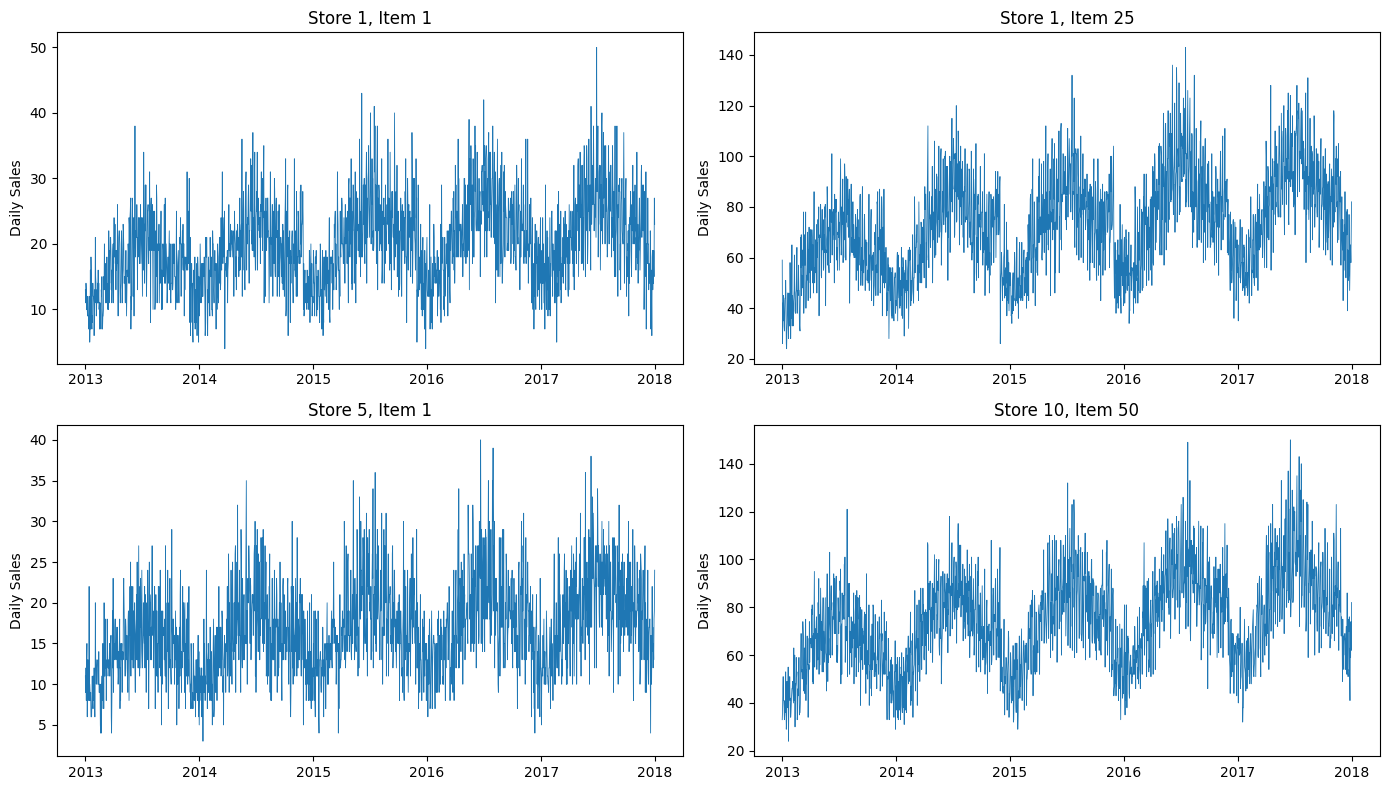

In [9]:
# Pick a few store-item combos to inspect individually
sample_combos = [
    (1, 1),    # store 1, item 1
    (1, 25),   # store 1, item 25 (mid-catalog)
    (5, 1),    # store 5, item 1 (different store, same item as first)
    (10, 50),  # store 10, item 50 (last store, last item)
]

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for i, (store, item) in enumerate(sample_combos):
    series = df[(df['store'] == store) & (df['item'] == item)]
    axes[i].plot(series['date'], series['sales'], linewidth=0.6)
    axes[i].set_title(f'Store {store}, Item {item}')
    axes[i].set_ylabel('Daily Sales')
    
plt.tight_layout()
plt.savefig('../sample_time_series.png', dpi=100, bbox_inches='tight')
plt.show()

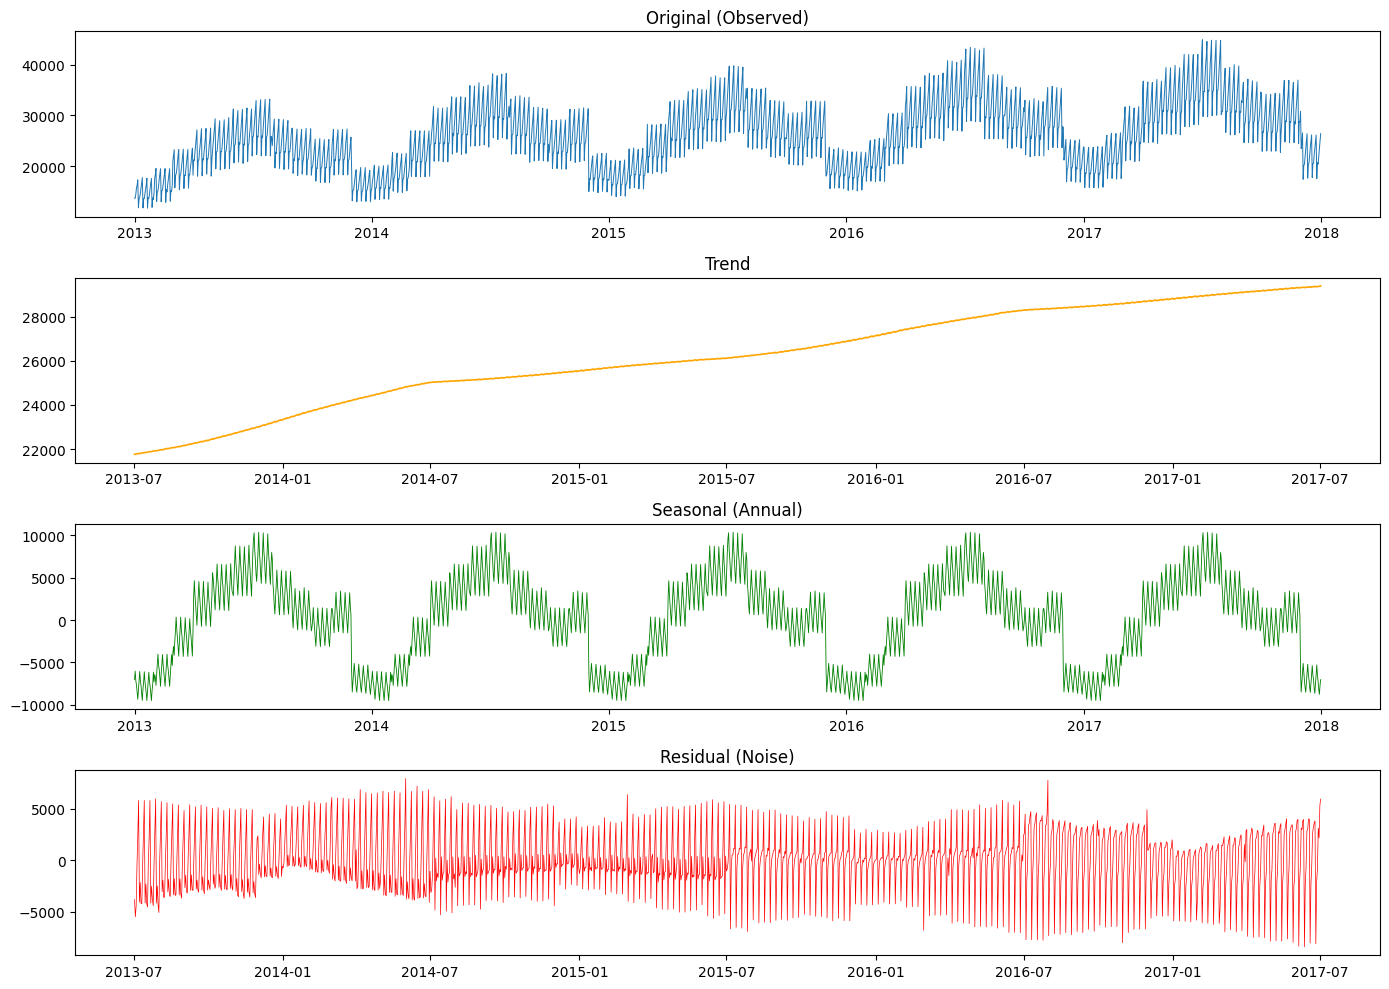

In [10]:
from statsmodels.tsa.seasonal import seasonal_decompose

# We need a clean time series with date as the index
ts = daily_total.set_index('date')['sales']

# Decompose with annual seasonality (period=365 days)
decomp = seasonal_decompose(ts, model='additive', period=365)

# Plot all 4 components: original, trend, seasonal, residual
fig, axes = plt.subplots(4, 1, figsize=(14, 10))

axes[0].plot(decomp.observed, linewidth=0.7)
axes[0].set_title('Original (Observed)')

axes[1].plot(decomp.trend, color='orange', linewidth=1.2)
axes[1].set_title('Trend')

axes[2].plot(decomp.seasonal, color='green', linewidth=0.6)
axes[2].set_title('Seasonal (Annual)')

axes[3].plot(decomp.resid, color='red', linewidth=0.5)
axes[3].set_title('Residual (Noise)')

plt.tight_layout()
plt.savefig('../decomposition.png', dpi=100, bbox_inches='tight')
plt.show()

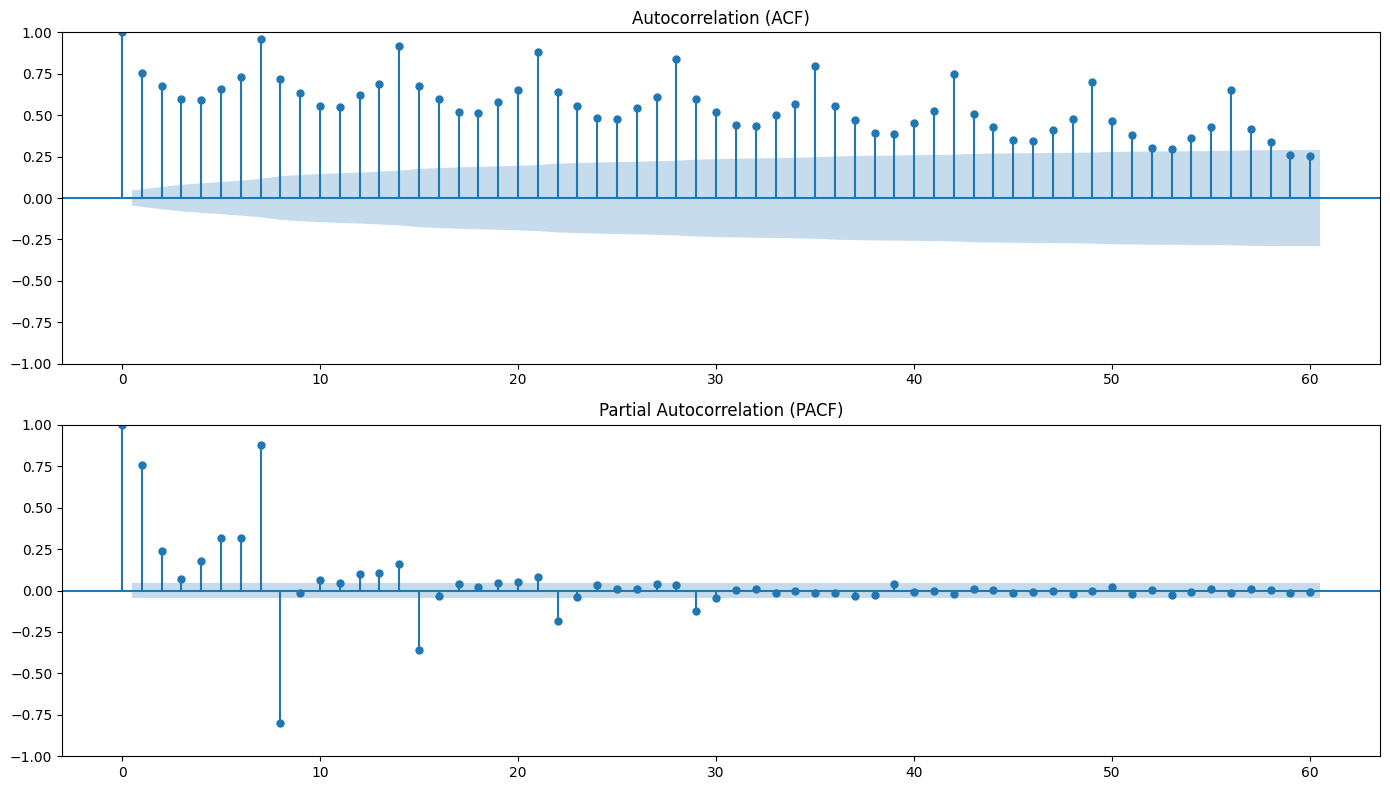

In [11]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# We'll plot ACF and PACF on the original total daily sales
# Lags up to 60 days — enough to see daily, weekly, and ~monthly patterns
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

plot_acf(ts, lags=60, ax=axes[0])
axes[0].set_title('Autocorrelation (ACF)')

plot_pacf(ts, lags=60, ax=axes[1], method='ywm')
axes[1].set_title('Partial Autocorrelation (PACF)')

plt.tight_layout()
plt.savefig('../acf_pacf.png', dpi=100, bbox_inches='tight')
plt.show()

### Initial Observations

- **Dataset:** 913,000 rows = 10 stores × 50 items × 1,826 days (5 years, 2013-2017). 500 distinct time series in total.
- **No missing values, no data quality issues** — clean dataset, can move directly to modeling pipeline.
- **Sales statistics:** range 0 to 231, mean ~52, integer-valued count data. Same family as my thesis target (mortality counts) — Poisson-like models will be appropriate.
- **Strong upward trend over 5 years** — sales are growing year-over-year; will need to handle non-stationarity before applying ARIMA.
- **Annual seasonality** with clear summer peaks (June-August). Suggests SARIMA with seasonal_period=365 or seasonal feature engineering.
- **Weekly cycle** visible in zoomed view — weekend peaks, weekday troughs. Will need to capture day-of-week in features for ML models.
- **Sample series are similar in shape, different in scale.** Inspected 4 store-item combos. All show same trend + seasonality + weekly pattern but at different magnitudes (peaks ~40 to ~140). This means a single model architecture should generalize across all 500 series — we won't need clustering or per-segment models.
- **Decomposition confirms 3 components:** clear upward trend, clean repeating annual seasonality, and residual showing weekly cycle (which annual decomposition didn't capture). Total demand has multi-scale seasonality — annual + weekly — both will need to be modeled.
- **ACF/PACF analysis confirms weekly seasonality (period=7).** PACF shows strong direct effects from lags 1-7 with a sharp cutoff at lag 8, indicating the weekly cycle dominates short-term prediction. ACF shows recurring spikes at lags 7, 14, 21, 28 — multi-week structure consistent with the residual pattern from decomposition.
- **Modeling implications:** The weekly cycle is the single strongest predictable signal. SARIMA with seasonal period=7 is a strong baseline candidate. For ML approaches (Random Forest, XGBoost), engineered lag features should include lag_1, lag_7, lag_14 at minimum, plus rolling statistics (7-day and 30-day means).

In [12]:
from statsmodels.tsa.stattools import adfuller, kpss

# Run ADF test on the original total daily sales
adf_result = adfuller(ts.dropna())
print("=== ADF Test (Augmented Dickey-Fuller) ===")
print(f"ADF Statistic: {adf_result[0]:.4f}")
print(f"p-value:       {adf_result[1]:.4f}")
print(f"Verdict:       {'STATIONARY' if adf_result[1] < 0.05 else 'NON-STATIONARY'}")
print()

# Run KPSS test
kpss_result = kpss(ts.dropna(), regression='c', nlags='auto')
print("=== KPSS Test ===")
print(f"KPSS Statistic: {kpss_result[0]:.4f}")
print(f"p-value:        {kpss_result[1]:.4f}")
print(f"Verdict:        {'STATIONARY' if kpss_result[1] > 0.05 else 'NON-STATIONARY'}")

=== ADF Test (Augmented Dickey-Fuller) ===
ADF Statistic: -3.0602
p-value:       0.0296
Verdict:       STATIONARY

=== KPSS Test ===
KPSS Statistic: 2.0010
p-value:        0.0100
Verdict:        NON-STATIONARY


C:\Users\NEXGEN\AppData\Local\Temp\ipykernel_5700\4062342713.py:12: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_result = kpss(ts.dropna(), regression='c', nlags='auto')


**Stationarity tests confirm non-stationarity.**  ADF (p < 0.05, rejects non-stationary null) and KPSS (p < 0.05, reject stationary null) agree the original series has a trend. ARIMA will need d=1 (one differencing step) to convert to stationary input.

In [13]:
# Split chronologically: train on 2013-2016, test on 2017
train = ts[ts.index < '2017-01-01']
test = ts[ts.index >= '2017-01-01']

print(f"Train: {len(train)} days, from {train.index.min().date()} to {train.index.max().date()}")
print(f"Test:  {len(test)} days, from {test.index.min().date()} to {test.index.max().date()}")

Train: 1461 days, from 2013-01-01 to 2016-12-31
Test:  365 days, from 2017-01-01 to 2017-12-31


Last training day value: 23792


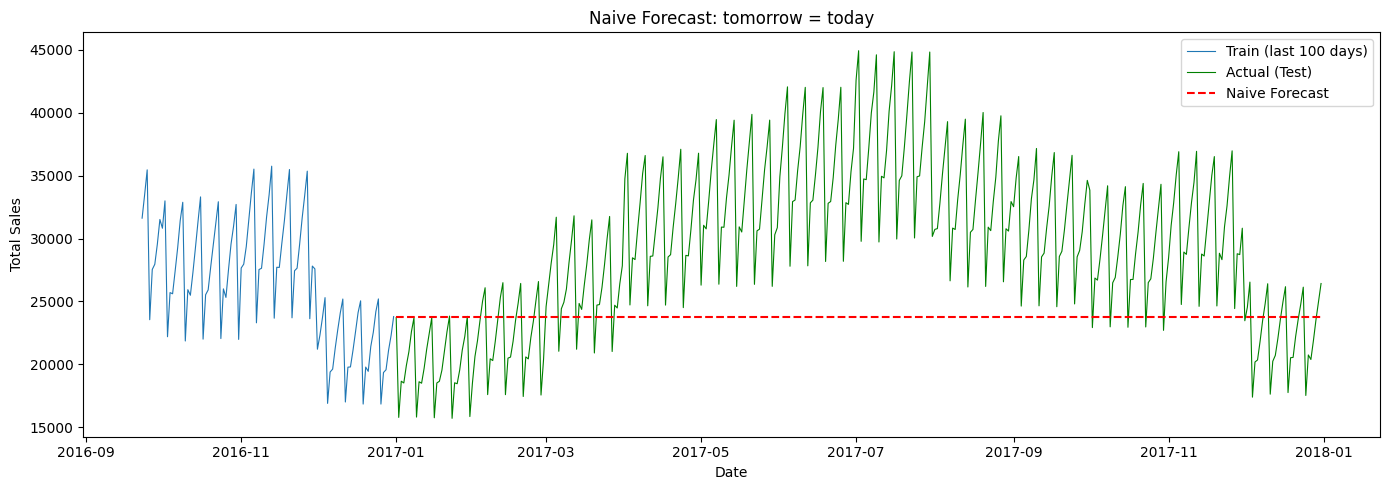

In [14]:
# The single value used for all naive predictions
naive_value = train.iloc[-1]
print(f"Last training day value: {naive_value}")

# Naive forecast: that value repeated for every test day
naive_forecast = pd.Series(
    [naive_value] * len(test),
    index=test.index
)

# Plot it
plt.figure(figsize=(14, 5))
plt.plot(train.index[-100:], train.values[-100:], label='Train (last 100 days)', linewidth=0.8)
plt.plot(test.index, test.values, label='Actual (Test)', linewidth=0.8, color='green')
plt.plot(naive_forecast.index, naive_forecast.values, label='Naive Forecast', linewidth=1.5, color='red', linestyle='--')
plt.title('Naive Forecast: tomorrow = today')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.legend()
plt.tight_layout()
plt.savefig('../naive_forecast.png', dpi=100, bbox_inches='tight')
plt.show()

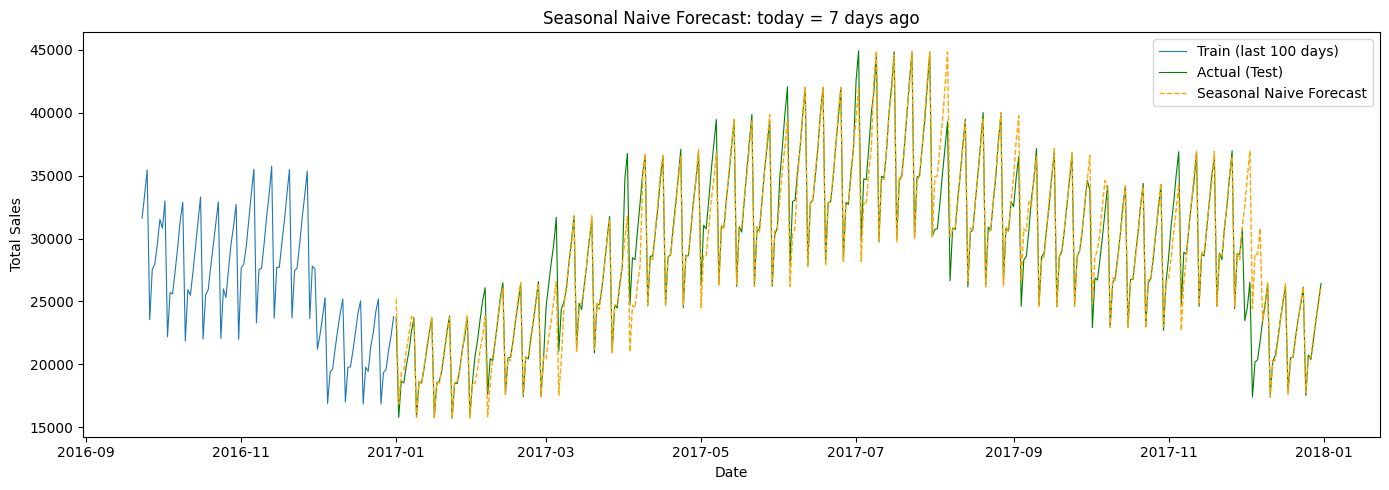

In [15]:
# For each test day, use the value from 7 days earlier
# We need the last 7 training days as the "lookup" for the first week of test
seasonal_naive_forecast = pd.Series(index=test.index, dtype=float)

for i, date in enumerate(test.index):
    # Look back 7 days in the combined train+test history
    lookup_date = date - pd.Timedelta(days=7)
    if lookup_date in train.index:
        seasonal_naive_forecast.iloc[i] = train.loc[lookup_date]
    elif lookup_date in test.index:
        # Use the previously-known test value (from a week ago)
        seasonal_naive_forecast.iloc[i] = test.loc[lookup_date]

# Plot it
plt.figure(figsize=(14, 5))
plt.plot(train.index[-100:], train.values[-100:], label='Train (last 100 days)', linewidth=0.8)
plt.plot(test.index, test.values, label='Actual (Test)', linewidth=0.8, color='green')
plt.plot(seasonal_naive_forecast.index, seasonal_naive_forecast.values, 
         label='Seasonal Naive Forecast', linewidth=1.0, color='orange', linestyle='--')
plt.title('Seasonal Naive Forecast: today = 7 days ago')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.legend()
plt.tight_layout()
plt.savefig('../seasonal_naive_forecast.png', dpi=100, bbox_inches='tight')
plt.show()

In [16]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

def evaluate_forecast(actual, predicted, model_name):
    """Compute RMSE, MAE, MAPE for a forecast."""
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mae = mean_absolute_error(actual, predicted)
    mape = np.mean(np.abs((actual - predicted) / actual)) * 100
    
    print(f"=== {model_name} ===")
    print(f"RMSE: {rmse:.2f}")
    print(f"MAE:  {mae:.2f}")
    print(f"MAPE: {mape:.2f}%")
    print()
    
    return {'model': model_name, 'RMSE': rmse, 'MAE': mae, 'MAPE': mape}

In [17]:
# Evaluate both baselines
results = []
results.append(evaluate_forecast(test, naive_forecast, 'Naive Forecast'))
results.append(evaluate_forecast(test, seasonal_naive_forecast, 'Seasonal Naive Forecast'))



=== Naive Forecast ===
RMSE: 8593.58
MAE:  7019.64
MAPE: 22.15%

=== Seasonal Naive Forecast ===
RMSE: 1868.41
MAE:  902.56
MAPE: 3.25%



### Baseline Forecasts

**Train/Test Split (chronological):**
- Train: 2013-01-01 to 2016-12-31 (1,461 days, ~80%)
- Test:  2017-01-01 to 2017-12-31 (365 days, ~20%)

**Baseline Results:**

| Model | RMSE | MAE | MAPE |
|---|---|---|---|
| Naive Forecast (today = yesterday) | 8593.58 | 7019.64 | 22.15% |
| Seasonal Naive Forecast (today = same day last week) | **1868.41** | **902.56** | **3.25%** |

**Key Findings:**
- **Seasonal Naive massively outperforms plain Naive** — 4.6× better RMSE, 6.8× better MAPE. Confirms the weekly cycle is the dominant predictable pattern.
- **3.25% MAPE is a high bar for ARIMA to beat.** With seasonal naive already capturing the weekly cycle so cleanly, ARIMA's job is to refine — capture residual structure beyond the weekly pattern (annual seasonality, trend acceleration, day-after-holiday effects).
- **Lesson:** for seasonal time series, simple seasonal-naive is a strong baseline that more complex models must earn improvements over. Always benchmark against it.

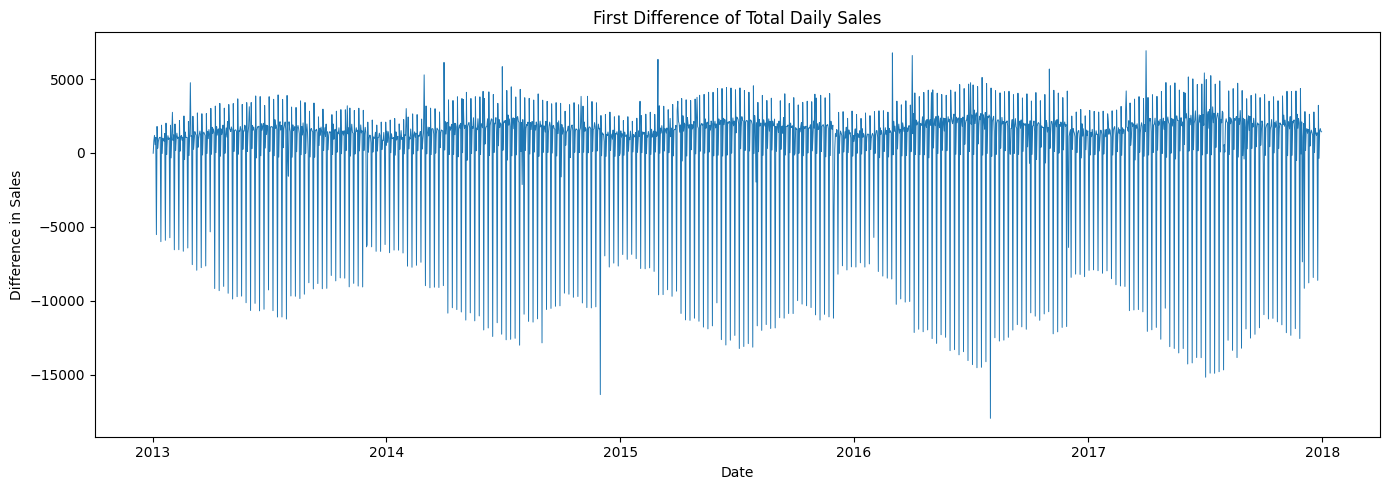

In [18]:
ts_diff = ts.diff().dropna()


plt.figure(figsize=(14, 5))
plt.plot(ts_diff, linewidth=0.7)
plt.title('First Difference of Total Daily Sales')
plt.xlabel('Date')
plt.ylabel('Difference in Sales')
plt.tight_layout()
plt.savefig('../first_difference.png', dpi=100, bbox_inches='tight')
plt.show()

In [19]:

adf_result_diff = adfuller(ts_diff)
print("=== ADF Test on First Difference ===")
print(f"ADF Statistic: {adf_result_diff[0]:.4f}")
print(f"p-value:       {adf_result_diff[1]:.4f}")
print(f"Verdict:       {'STATIONARY' if adf_result_diff[1] < 0.05 else 'NON-STATIONARY'}")
kpss_result_df = kpss(ts_diff, regression='c', nlags='auto')
print("\n=== KPSS Test on First Difference ===")
print(f"KPSS Statistic: {kpss_result_df[0]:.4f}")
print(f"p-value:        {kpss_result_df[1]:.4f}")
print(f"Verdict:        {'STATIONARY' if kpss_result_df[1] > 0.05 else 'NON-STATIONARY'}")

=== ADF Test on First Difference ===
ADF Statistic: -8.9190
p-value:       0.0000
Verdict:       STATIONARY

=== KPSS Test on First Difference ===
KPSS Statistic: 0.0511
p-value:        0.1000
Verdict:        STATIONARY


C:\Users\NEXGEN\AppData\Local\Temp\ipykernel_5700\3626427667.py:6: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result_df = kpss(ts_diff, regression='c', nlags='auto')


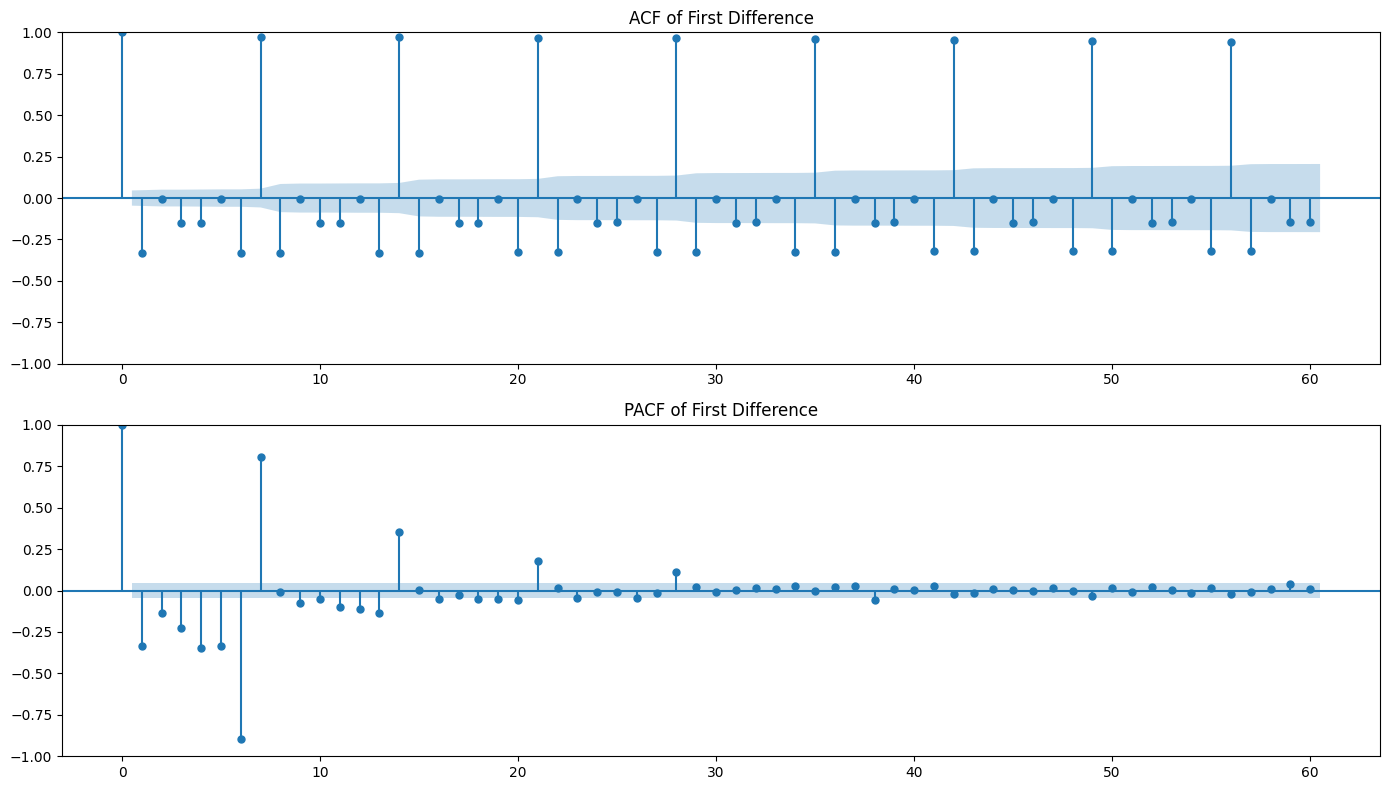

In [20]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))
plot_acf(ts_diff, lags=60, ax=axes[0])
axes[0].set_title('ACF of First Difference')
plot_pacf(ts_diff, lags=60, ax=axes[1], method='ywm')
axes[1].set_title('PACF of First Difference')
plt.tight_layout()
plt.savefig('../acf_pacf_diff.png', dpi=100, bbox_inches='tight')
plt.show()

In [21]:
from statsmodels.tsa.arima.model import ARIMA

arima_model = ARIMA(train, order=(1,1,1))
arima_result = arima_model.fit()
print(arima_result.summary())
arima_forecast = arima_result.get_forecast(steps=len(test))
arima_forecast.index = test.index  # Align forecast index with test index for evaluation

c:\Users\NEXGEN\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\NEXGEN\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\NEXGEN\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                  sales   No. Observations:                 1461
Model:                 ARIMA(1, 1, 1)   Log Likelihood              -14014.271
Date:                Mon, 18 May 2026   AIC                          28034.542
Time:                        16:22:22   BIC                          28050.401
Sample:                    01-01-2013   HQIC                         28040.458
                         - 12-31-2016                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2194      0.034      6.465      0.000       0.153       0.286
ma.L1         -0.8956      0.017    -52.619      0.000      -0.929      -0.862
sigma2      1.272e+07   1.36e-09   9.34e+15      0.0

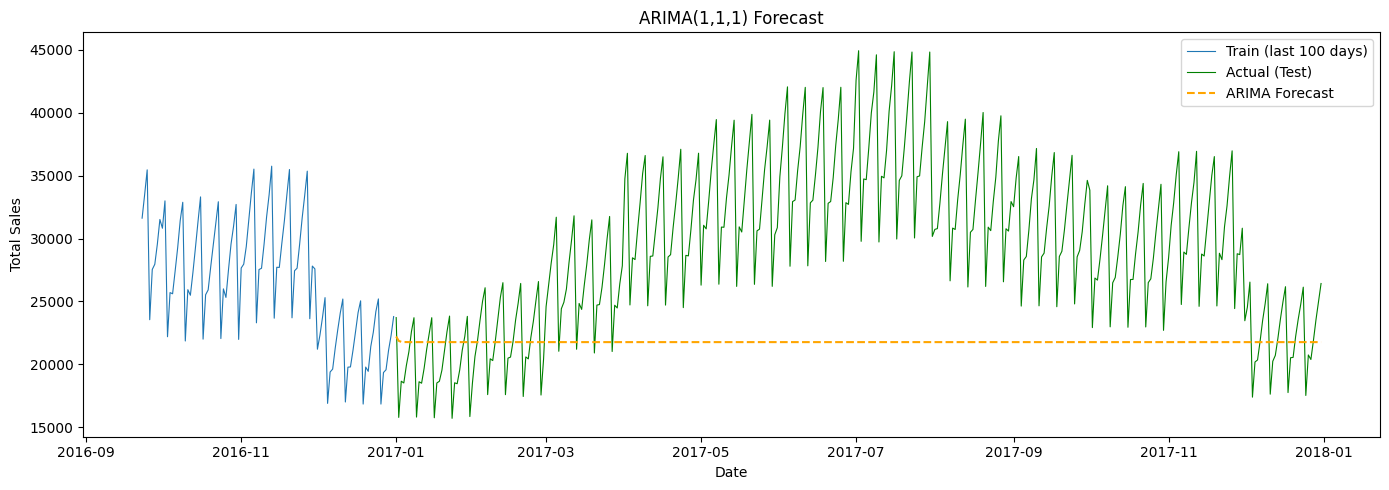

In [22]:
plt.figure(figsize=(14, 5))
plt.plot(train.index[-100:], train.values[-100:], label='Train (last 100 days)', linewidth=0.8)
plt.plot(test.index, test.values, label='Actual (Test)', linewidth=0.8, color='green')
plt.plot(arima_forecast.predicted_mean.index, arima_forecast.predicted_mean.values, label='ARIMA Forecast', color="orange",linewidth=1.5,  linestyle='--')
plt.title('ARIMA(1,1,1) Forecast')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.tight_layout()
plt.legend()
plt.savefig('../arima_forecast.png', dpi=100, bbox_inches='tight')
plt.show()

In [23]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

sarima_model = SARIMAX(
    train,
    order=(1,1,1),        # ARIMA part
    seasonal_order=(1,1,1,7)  # SARIMA part with weekly seasonality (period=7)
)

sarima_result = sarima_model.fit(disp=False)
print(sarima_result.summary())

sarima_forecast = sarima_result.get_forecast(steps=len(test))
sarima_forecast.index = test.index  # Align forecast index with test index for evaluation

c:\Users\NEXGEN\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\NEXGEN\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                     
Dep. Variable:                             sales   No. Observations:                 1461
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 7)   Log Likelihood              -11719.004
Date:                           Mon, 18 May 2026   AIC                          23448.008
Time:                                   16:22:30   BIC                          23474.415
Sample:                               01-01-2013   HQIC                         23457.861
                                    - 12-31-2016                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9294      0.008    122.541      0.000       0.915       0.944
ma.L1         -1.0000      0.009   -108.590

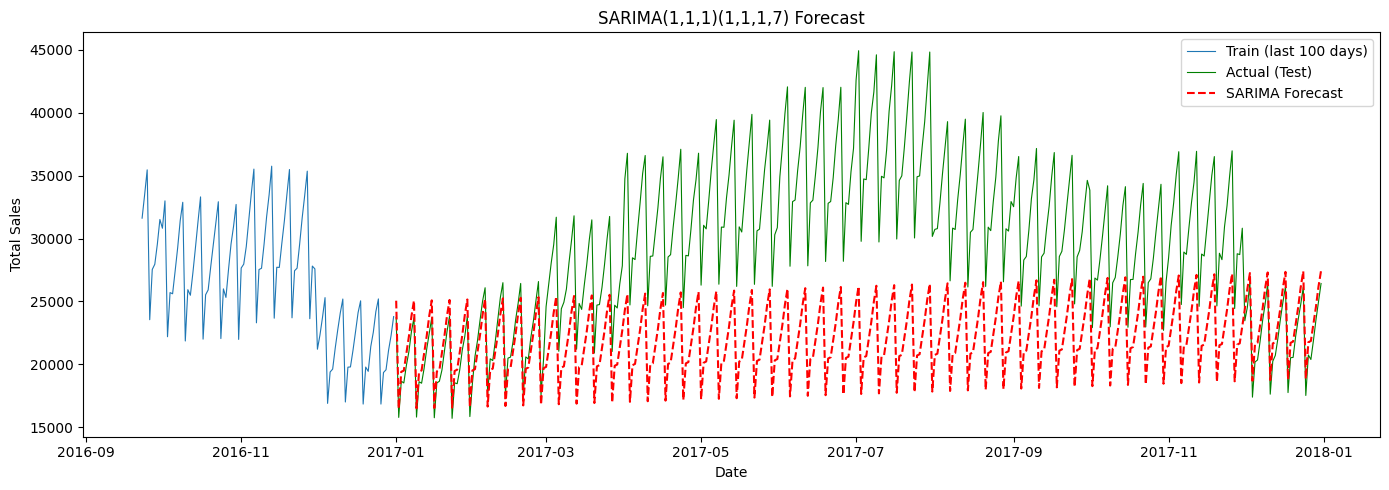

In [24]:
plt.figure(figsize=(14, 5))
plt.plot(train.index[-100:], train.values[-100:], label='Train (last 100 days)', linewidth=0.8)
plt.plot(test.index, test.values, label='Actual (Test)', linewidth=0.8, color='green')
plt.plot(sarima_forecast.predicted_mean.index, sarima_forecast.predicted_mean.values, label='SARIMA Forecast', color="red", linewidth=1.5, linestyle='--')
plt.title('SARIMA(1,1,1)(1,1,1,7) Forecast')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.legend()
plt.tight_layout()
plt.savefig('../sarima_forecast.png', dpi=100, bbox_inches='tight')
plt.show()

In [25]:
results.append(evaluate_forecast(test, naive_forecast, 'Naive Forecast'))
results.append(evaluate_forecast(test, seasonal_naive_forecast, 'Seasonal Naive Forecast'))
results.append(evaluate_forecast(test, arima_forecast.predicted_mean, 'ARIMA(1,1,1)'))
results.append(evaluate_forecast(test, sarima_forecast.predicted_mean, 'SARIMA(1,1,1)(1,1,1,7)'))

=== Naive Forecast ===
RMSE: 8593.58
MAE:  7019.64
MAPE: 22.15%

=== Seasonal Naive Forecast ===
RMSE: 1868.41
MAE:  902.56
MAPE: 3.25%

=== ARIMA(1,1,1) ===
RMSE: 10039.96
MAE:  8344.24
MAPE: 25.84%

=== SARIMA(1,1,1)(1,1,1,7) ===
RMSE: 8979.64
MAE:  7593.77
MAPE: 23.62%



In [26]:
len(test)

365

In [27]:
import time

history = list(train.values)
walk_forward_predictions = []
step_size = 7  # Weekly seasonality


start_time = time.time()
n_steps = len(test) //step_size

for i in range(n_steps):
    model = SARIMAX(history, order=(1,1,1), seasonal_order=(1,1,1,7))
    model_fit = model.fit(disp=False)
    
    forecast = model_fit.forecast(steps=step_size)
    walk_forward_predictions.extend(forecast)
    
    actual_next = test.values[i*step_size:(i+1)*step_size]
    history.extend(actual_next)
    
    if(i+1) % 10 == 0:
        elapsed = time.time() - start_time
        print(f"Completed {i+1}/{n_steps} steps, elapsed time: {elapsed:.2f} seconds")
        
elapsed_total = time.time() - start_time
print(f"\nDone. Total time:{elapsed_total:.2f} seconds")

wf_forecast = pd.Series(
    walk_forward_predictions,
    index=test.index[:len(walk_forward_predictions)]
)

test_aligned = test.iloc[:len(wf_forecast)]
wf_metrics = evaluate_forecast(test_aligned, wf_forecast, 'Walk-Forward SARIMA')
results.append(wf_metrics)

Completed 10/52 steps, elapsed time: 34.99 seconds
Completed 20/52 steps, elapsed time: 82.75 seconds
Completed 30/52 steps, elapsed time: 134.18 seconds
Completed 40/52 steps, elapsed time: 180.03 seconds


c:\Users\NEXGEN\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Completed 50/52 steps, elapsed time: 220.27 seconds

Done. Total time:232.94 seconds
=== Walk-Forward SARIMA ===
RMSE: 1315.68
MAE:  696.06
MAPE: 2.48%



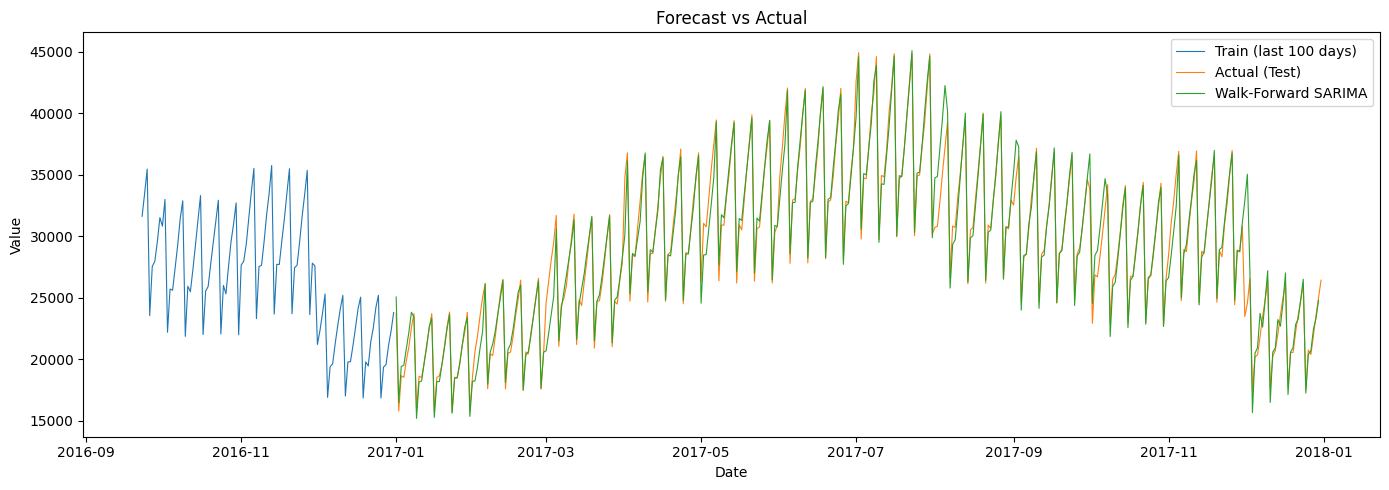

In [28]:
plt.figure(figsize=(14, 5))
plt.plot(train.index[-100:], train.values[-100:], label='Train (last 100 days)', linewidth=0.8)
plt.plot(test.index, test.values, label='Actual (Test)', linewidth=0.8)
plt.plot(wf_forecast.index, wf_forecast.values, label='Walk-Forward SARIMA', linewidth=0.8)
plt.xlabel('Date')
plt.ylabel('Value')
plt.title('Forecast vs Actual')
plt.legend()
plt.tight_layout()
plt.savefig('../walk_forward_sarima.png', dpi=100, bbox_inches='tight')
plt.show()

***ML Methods

In [29]:
df_ml = pd.DataFrame({'sales': ts})
df_ml['lag_1'] = df_ml['sales'].shift(1)
df_ml['lag_7'] = df_ml['sales'].shift(7)
df_ml['lag_14'] = df_ml['sales'].shift(14)
df_ml['lag_30'] = df_ml['sales'].shift(30)

df_ml['rolling_mean_7'] = df_ml['sales'].shift(1).rolling(window=7).mean()
df_ml['rolling_mean_30'] = df_ml['sales'].shift(1).rolling(window=30).mean()

df_ml['day_of_week'] = df_ml.index.dayofweek
df_ml['month'] = df_ml.index.month
df_ml['day_of_month'] = df_ml.index.day

df_ml = df_ml.dropna()


print(df_ml.shape)
print(df_ml.head())

(1796, 10)
            sales    lag_1    lag_7   lag_14   lag_30  rolling_mean_7  \
date                                                                    
2013-01-31  14724  13391.0  14472.0  14587.0  13696.0    14745.000000   
2013-02-01  17473  14724.0  15640.0  15495.0  13678.0    14781.000000   
2013-02-02  18323  17473.0  16561.0  16294.0  14488.0    15042.857143   
2013-02-03  19544  18323.0  17579.0  17612.0  15677.0    15294.571429   
2013-02-04  12998  19544.0  11848.0  11709.0  16237.0    15575.285714   

            rolling_mean_30  day_of_week  month  day_of_month  
date                                                           
2013-01-31     14672.666667            3      1            31  
2013-02-01     14706.933333            4      2             1  
2013-02-02     14833.433333            5      2             2  
2013-02-03     14961.266667            6      2             3  
2013-02-04     15090.166667            0      2             4  


In [30]:
X = df_ml.drop('sales', axis=1)
y = df_ml['sales']

train_cutoff = '2017-01-01'
X_train = X[X.index < train_cutoff]
X_test = X[X.index >= train_cutoff]
y_train = y[y.index < train_cutoff]
y_test = y[y.index >= train_cutoff]

print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test:  {y_test.shape}")

X_train: (1431, 9)
X_test:  (365, 9)
y_train: (1431,)
y_test:  (365,)


In [31]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)
rf_forecast = pd.Series(rf_predictions, index=X_test.index)

print(f"Random Forest trained on {len(X_train)} days, predicting {len(X_test)} days")

Random Forest trained on 1431 days, predicting 365 days


In [32]:
rf_metrics = evaluate_forecast(y_test, rf_forecast, "Random Forest (lag features)")
results.append(rf_metrics)

=== Random Forest (lag features) ===
RMSE: 1061.39
MAE:  622.71
MAPE: 2.19%



In [33]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)

xgb_predictions = xgb_model.predict(X_test)
xgb_forecast = pd.Series(xgb_predictions, index=X_test.index)

xgb_metrics = evaluate_forecast(y_test, xgb_forecast, "XGBoost (lag features)")
results.append(xgb_metrics)

=== XGBoost (lag features) ===
RMSE: 993.75
MAE:  611.66
MAPE: 2.09%



In [40]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('MAPE').reset_index(drop=True)
results_df['Rank'] = results_df.index + 1

print("="*60)
print("FINAL MODEL COMPARISON")
print("="*60)
print(results_df.to_string(index=False))

results_df.to_csv('../results/model_comparison.csv', index=False)
print("\nSaved to ../results/model_comparison.csv")

FINAL MODEL COMPARISON
                       model         RMSE         MAE      MAPE  Rank
      XGBoost (lag features)   993.752421  611.658936  2.094671     1
Random Forest (lag features)  1061.390252  622.714990  2.190586     2
         Walk-Forward SARIMA  1315.675188  696.059661  2.479563     3
     Seasonal Naive Forecast  1868.413821  902.561644  3.245869     4
     Seasonal Naive Forecast  1868.413821  902.561644  3.245869     5
              Naive Forecast  8593.583180 7019.638356 22.147774     6
              Naive Forecast  8593.583180 7019.638356 22.147774     7
      SARIMA(1,1,1)(1,1,1,7)  8979.642658 7593.770178 23.615395     8
                ARIMA(1,1,1) 10039.960803 8344.236748 25.840519     9

Saved to ../results/model_comparison.csv


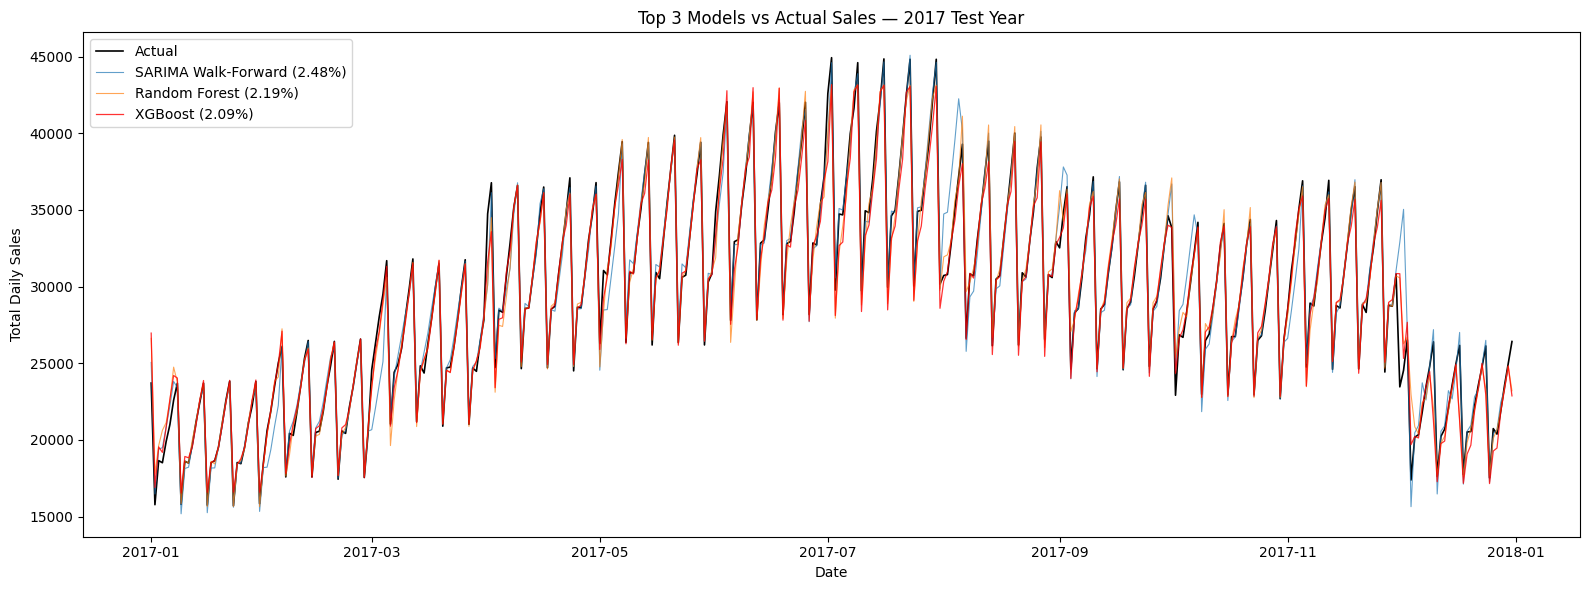

In [35]:
plt.figure(figsize=(16, 6))

plt.plot(y_test.index, y_test.values,
         label='Actual', linewidth=1.2, color='black')
plt.plot(wf_forecast.index, wf_forecast.values,
         label='SARIMA Walk-Forward (2.48%)', linewidth=0.8, alpha=0.7)
plt.plot(rf_forecast.index, rf_forecast.values,
         label='Random Forest (2.19%)', linewidth=0.8, alpha=0.7)
plt.plot(xgb_forecast.index, xgb_forecast.values,
         label='XGBoost (2.09%)', linewidth=0.9, color='red', alpha=0.8)

plt.title('Top 3 Models vs Actual Sales — 2017 Test Year')
plt.xlabel('Date')
plt.ylabel('Total Daily Sales')
plt.legend(loc='upper left')
plt.tight_layout()
plt.savefig('../results/forecast_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

=== XGBoost Feature Importance ===
        feature  importance
          lag_7    0.886372
          lag_1    0.054507
          month    0.028735
   day_of_month    0.010546
    day_of_week    0.010090
         lag_14    0.003713
 rolling_mean_7    0.003363
         lag_30    0.001874
rolling_mean_30    0.000799


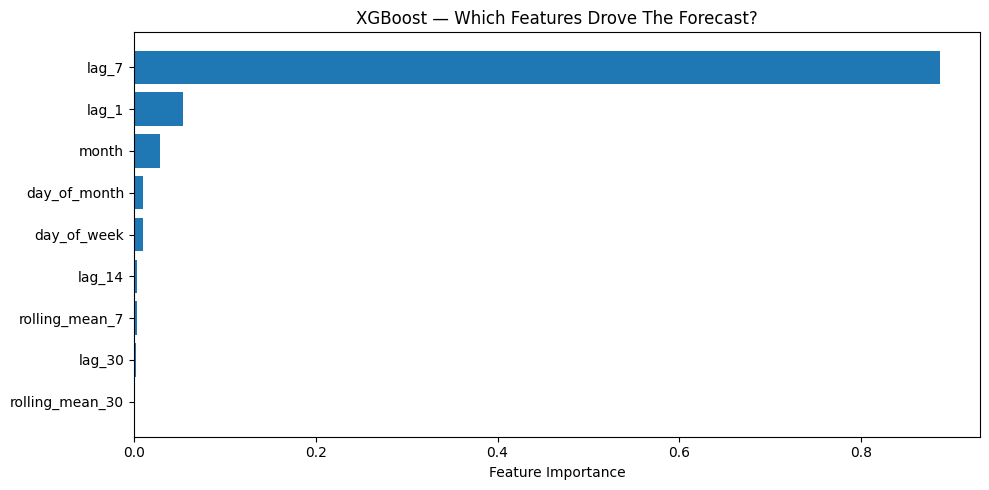

In [36]:
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False)

print("=== XGBoost Feature Importance ===")
print(feature_importance.to_string(index=False))

plt.figure(figsize=(10, 5))
plt.barh(feature_importance['feature'], feature_importance['importance'])
plt.gca().invert_yaxis()
plt.xlabel('Feature Importance')
plt.title('XGBoost — Which Features Drove The Forecast?')
plt.tight_layout()
plt.savefig('../results/feature_importance.png', dpi=100, bbox_inches='tight')
plt.show()

## Final Results — Project Summary

### Scoreboard

| Rank | Model | RMSE | MAE | MAPE |
|------|-------|------|-----|------|
| 🥇 | **XGBoost (lag features)** | **993.75** | **611.66** | **2.09%** |
| 🥈 | Random Forest (lag features) | 1061.39 | 622.71 | 2.19% |
| 🥉 | SARIMA Walk-Forward | 1315.68 | 696.06 | 2.48% |
| 4 | Seasonal Naive | 1868.41 | 902.56 | 3.25% |
| 5 | Naive | 8593.58 | 7019.64 | 22.15% |
| 6 | SARIMA single-shot | 8979.64 | 7593.77 | 23.62% |
| 7 | ARIMA single-shot | 10039.96 | 8344.24 | 25.84% |

### Key Findings

1. **XGBoost wins overall** at 2.09% MAPE, beating SARIMA Walk-Forward on every metric.

2. **Single-shot classical models fail** on long horizons. ARIMA and SARIMA predictions revert to the mean over 365 days, performing worse than the naive baseline.

3. **Walk-forward evaluation recovers SARIMA** to 2.48% MAPE — proving that deployment-realistic evaluation matters as much as algorithm choice.

4. **Feature engineering wins**. The ML edge over SARIMA came from access to calendar features (`day_of_week`, `month`) that classical models cannot use.

5. **lag_7 explains 89% of XGBoost's forecast** — confirming weekly seasonality dominates. The model essentially refines seasonal naive's logic with small calendar-based corrections.

### Methodology Notes

- **Chronological split** (train: 2013-2016, test: 2017) — never used `train_test_split` to prevent temporal data leakage.
- **Leak-safe rolling means** — `.shift(1)` applied before `.rolling().mean()` to prevent the target from leaking into its own features.
- **Same test period** across all 7 models for fair comparison.
- All models evaluated using RMSE, MAE, and MAPE on identical test data.